In [1]:
!pip install streamlit pyngrok pandas numpy scikit-learn matplotlib seaborn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 124.7 MB/s eta 0:00:00


In [2]:
# Network Anomaly Detection using Machine Learning
### NSL-KDD Dataset | Author: Bairi Pawan Kumar


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_curve, roc_auc_score
)
from sklearn.decomposition import PCA

print('All libraries imported successfully.')

All libraries imported successfully.


In [4]:
df_train = pd.read_csv('train.csv')
df_test  = pd.read_csv('test.csv')

# Combine for unified preprocessing
df = pd.concat([df_train, df_test], ignore_index=True)

print('Train Shape:', df_train.shape)
print('Test Shape :', df_test.shape)
print('Combined   :', df.shape)
df.head()

Train Shape: (151165, 42)
Test Shape : (34394, 42)
Combined   : (185559, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [5]:
# Convert multi-class labels to binary: normal / attack
df['class'] = df['class'].apply(
    lambda x: 'normal' if x.strip().lower() == 'normal' else 'attack'
)

print('Label distribution:')
print(df['class'].value_counts())

Label distribution:
class
attack    92904
normal    92655
Name: count, dtype: int64


In [6]:
# Encode all categorical (object) columns using LabelEncoder
label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    if col == 'class':
        continue  # encode target separately
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
# Encode target column
target_encoder = LabelEncoder()
df['class'] = target_encoder.fit_transform(df['class'])  # normal=1, attack=0

print('Encoding complete. Classes:', target_encoder.classes_)



Encoding complete. Classes: ['attack' 'normal']


In [7]:
X = df.drop('class', axis=1)
y = df['class']

# Split BEFORE scaling to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Scale AFTER split (fit on train only)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Save scaler for Streamlit app
pickle.dump(scaler, open('scaler.pkl', 'wb'))

print('Training samples:', X_train.shape[0])
print('Testing samples :', X_test.shape[0])


Training samples: 129891
Testing samples : 55668



--- Random Forest ---
Accuracy: 0.9971
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27871
           1       1.00      1.00      1.00     27797

    accuracy                           1.00     55668
   macro avg       1.00      1.00      1.00     55668
weighted avg       1.00      1.00      1.00     55668



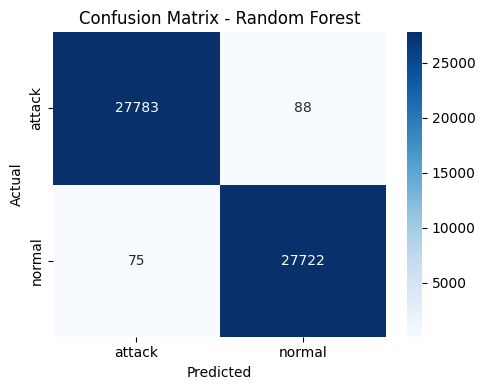


--- SVM ---
Accuracy: 0.9803
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     27871
           1       0.98      0.98      0.98     27797

    accuracy                           0.98     55668
   macro avg       0.98      0.98      0.98     55668
weighted avg       0.98      0.98      0.98     55668



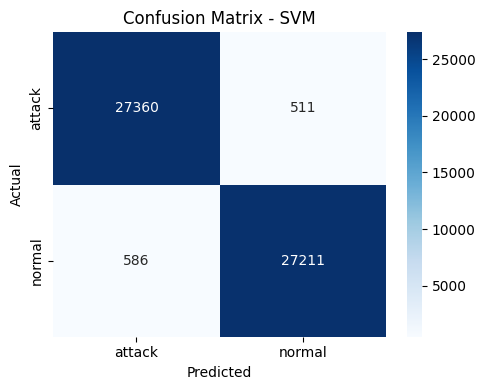


--- KNN ---
Accuracy: 0.9907
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     27871
           1       0.99      0.99      0.99     27797

    accuracy                           0.99     55668
   macro avg       0.99      0.99      0.99     55668
weighted avg       0.99      0.99      0.99     55668



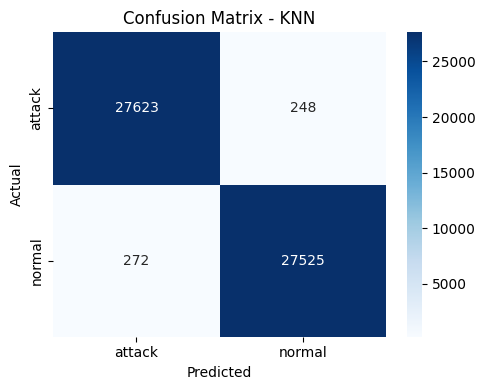

In [8]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'          : SVC(probability=True, random_state=42),
    'KNN'          : KNeighborsClassifier(n_neighbors=5)
}

model_results = {}
trained_models = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    model_results[name]  = acc
    trained_models[name] = clf

    print(f'\n--- {name} ---')
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_encoder.classes_,
                yticklabels=target_encoder.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

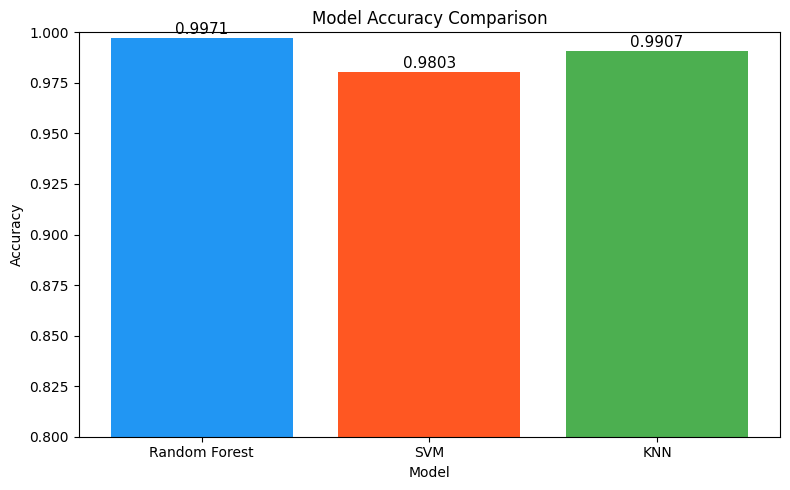

Best Model: Random Forest (0.9971)
model.pkl saved (Random Forest)


In [9]:
plt.figure(figsize=(8, 5))
bars = plt.bar(model_results.keys(), model_results.values(),
               color=['#2196F3', '#FF5722', '#4CAF50'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)

for bar, acc in zip(bars, model_results.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

best_model_name = max(model_results, key=model_results.get)
print(f'Best Model: {best_model_name} ({model_results[best_model_name]:.4f})')

# Save best model for Streamlit app
pickle.dump(trained_models[best_model_name], open('model.pkl', 'wb'))
print(f'model.pkl saved ({best_model_name})')

Isolation Forest Accuracy: 0.4475


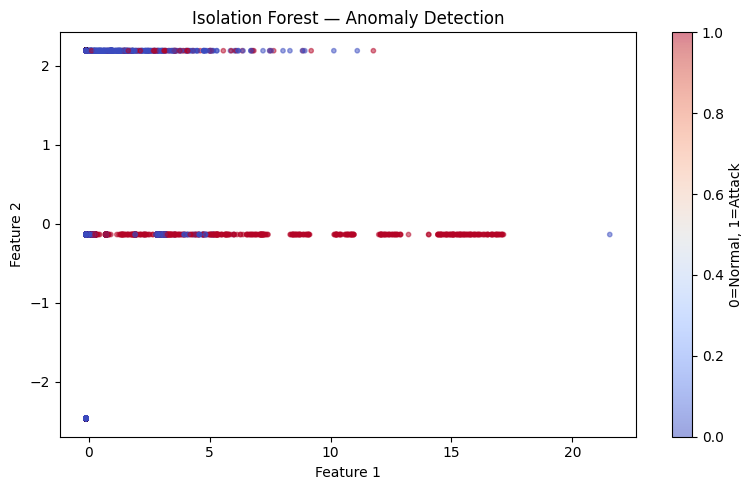

In [10]:
iso = IsolationForest(contamination=0.1, random_state=42)
iso.fit(X_train)

iso_pred = iso.predict(X_test)
iso_pred = np.where(iso_pred == -1, 1, 0)  # -1=anomaly → 1, else 0

iso_acc = accuracy_score(y_test, iso_pred)
print(f'Isolation Forest Accuracy: {iso_acc:.4f}')

plt.figure(figsize=(8, 5))
plt.scatter(X_test[:, 0], X_test[:, 1],
            c=iso_pred, cmap='coolwarm', alpha=0.5, s=10)
plt.title('Isolation Forest — Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='0=Normal, 1=Attack')
plt.tight_layout()
plt.show()

Top 10 Features:
               Feature  Importance
             src_bytes    0.198682
             dst_bytes    0.103090
    dst_host_srv_count    0.063735
                  flag    0.063684
dst_host_same_srv_rate    0.058115
         same_srv_rate    0.055824
             logged_in    0.043165
               service    0.036567
         protocol_type    0.035646
         diff_srv_rate    0.032641


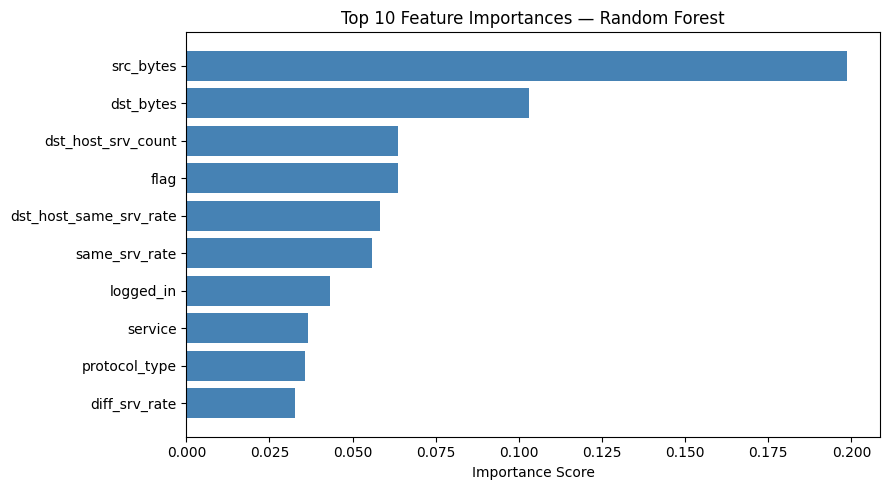

In [11]:
rf = trained_models['Random Forest']
feature_names = df.drop('class', axis=1).columns

feature_importance = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print('Top 10 Features:')
print(feature_importance.head(10).to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(feature_importance['Feature'][:10][::-1],
         feature_importance['Importance'][:10][::-1],
         color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

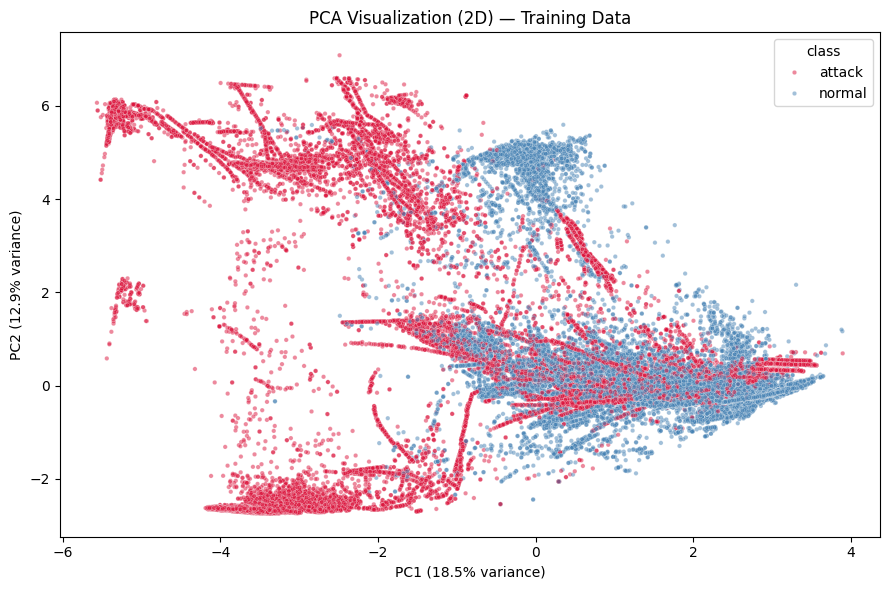

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=y_train.map({0: 'attack', 1: 'normal'}),
    palette={'normal': 'steelblue', 'attack': 'crimson'},
    alpha=0.5, s=10
)
plt.title('PCA Visualization (2D) — Training Data')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

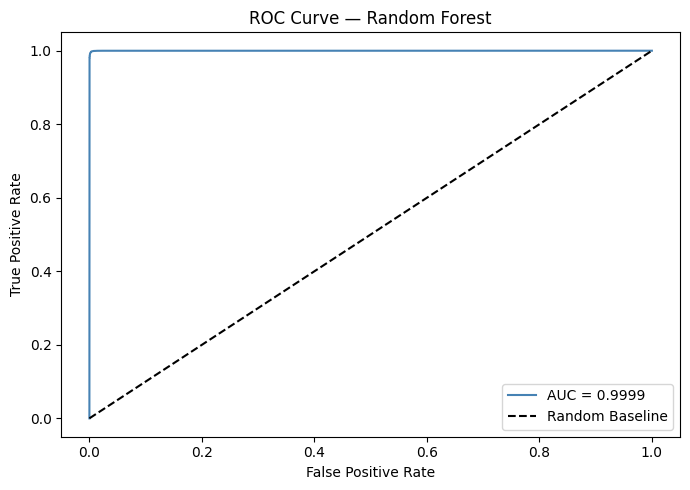

In [13]:
y_prob = rf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc     = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.title('ROC Curve — Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
print('=' * 40)
print('       PROJECT SUMMARY')
print('=' * 40)
for name, acc in model_results.items():
    print(f'{name:<20}: {acc:.4f} ({acc*100:.2f}%)')
print('-' * 40)
print(f'Best Model : {best_model_name}')
print(f'ROC AUC    : {roc_auc:.4f}')
print('=' * 40)
print('model.pkl  and scaler.pkl saved for deployment.')


       PROJECT SUMMARY
Random Forest       : 0.9971 (99.71%)
SVM                 : 0.9803 (98.03%)
KNN                 : 0.9907 (99.07%)
----------------------------------------
Best Model : Random Forest
ROC AUC    : 0.9999
model.pkl  and scaler.pkl saved for deployment.


In [15]:
!pip install streamlit pyngrok

In [16]:
!ls

app.py	drive  model.pkl  sample_data  scaler.pkl  test.csv  train.csv


In [17]:
!ngrok config add-authtoken 3DnFKiUZYVl9sNhNSUHxZjD9SXN_3HrPPx5rccT8suBpxx2bu

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [18]:
!streamlit run app.py &>/content/logs.txt &

In [19]:
from pyngrok import ngrok

ngrok.kill()
public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://absolute-retired-irritably.ngrok-free.dev" -> "http://localhost:8501"


In [21]:
from google.colab import files

files.download("model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>